# 🛠️ Milestone 4: Preprocessing & Feature Engineering

**Project:** Network Intrusion Detection System (CICIDS-2017)   
**Team:**  – Dina Fawzy – Mohamed Farag – Pola Mokhtar – Ahmed Mamdouh – Mustafa Ibrahim  
**Team Leader:** Ahmed Mamdouh   
**Google Drive:** https://drive.google.com/drive/folders/1wa5Y5heNduaFH-T2bIkQAkoXlhiy0QCe?usp=sharing  
**Github Repo:** https://github.com/AhmedELNajjar-dev/Depi-Final-Project  
**Goal:** To transform the cleaned dataset into a mathematically optimized format ready for Machine Learning.
### 📋 Overview
In this milestone, we implement the feature selection and preprocessing methodology described in **Section 3.5** of the research paper. Our objective is to reduce the dimensionality of the data while retaining the most predictive behavioral features.

### 🚀 Steps to be Performed:
1.  **Import Libraries:** Load necessary tools for data manipulation.
2.  **Load Cleaned Data:** Import the dataset from Milestone 2.
3.  **Drop Metadata:** Remove non-behavioral columns (IPs, Timestamps) to prevent model overfitting.
4.  **Label Grouping:** Map the 15 specific attack labels into the 7 main categories used in **Table 3** of the paper.
5.  **Zero-Variance Removal:** mathematically prove and remove features that contain no information (standard deviation = 0).
6.  **Correlation Analysis:** Identify and remove highly correlated features (threshold $\ge 0.95$) to reduce redundancy.
7.  **Class Balancing:** Apply the paper's **80/20 Random Undersampling** strategy to handle the severe class imbalance.
8.  **Save Final Data:** Export the optimized `ML_Data_Balanced.parquet` file.

# 1️⃣ Import Libraries
We import `pandas` and `numpy` for data manipulation and `seaborn`/`matplotlib` to visualize our feature selection "proofs."

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.preprocessing import LabelEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2️⃣ Load Cleaned Data
We load the dataset saved in the previous milestone. We use the **Parquet** format to ensure that our optimized data types (`int8`, `int32`, `float64`) are preserved, keeping memory usage low.

In [ ]:

parquet_path = "/content/drive/MyDrive/Depi Project/Cleaned Data/Cleaned_Data.parquet"
df = pd.read_parquet(parquet_path)

print("Data loaded from Parquet with all data types preserved!")


Data loaded from Parquet with all data types preserved!


In [ ]:
df.shape

(2520158, 84)

# 3️⃣ Remove Metadata Columns
**Rationale:** The Machine Learning model must detect attacks based on *network behavior* (e.g., packet size, inter-arrival time), not by memorizing specific identifiers.

We drop the following columns:
* **IP Addresses:** `Source IP`, `Destination IP`
* **Ports:** `Source Port`
* **Time:** `Timestamp`
* **Protocol:** `Protocol`

In [ ]:
# Define metadata columns to drop
metadata_cols_for_dedup = [
    'Flow ID',
    'Source IP',
    'Source Port',
    'Timestamp'
]
print("Dropping Metadata Columns...")
df.drop(columns=metadata_cols_for_dedup, inplace=True, errors='ignore')

print(f"Shape after dropping metadata: {df.shape}")

Dropping Metadata Columns...
Shape after dropping metadata: (2520158, 80)


#4️⃣ Label Grouping (Target Engineering)
**Rationale:** To match the methodology in the research paper (**Table 3**), we simplify the 15 distinct attack labels into 7 broader categories.

* **DoS:** Combines *DDoS, DoS Hulk, GoldenEye, Slowloris, Slowhttptest, Heartbleed*.
* **Brute Force:** Combines *FTP-Patator* and *SSH-Patator*.
* **Web Attack:** Combines *Brute Force, XSS, and SQL Injection*.

In [ ]:
# Mapping based on Table 3 of the paper
label_mapping_ml = {
    'BENIGN': 'BENIGN',
    'DDoS': 'DoS', 'DoS Hulk': 'DoS', 'DoS GoldenEye': 'DoS', 'DoS slowloris': 'DoS',
    'DoS Slowhtt_test': 'DoS', 'DoS Slowhttptest': 'DoS', 'Heartbleed': 'DoS',
    'PortScan': 'PortScan',
    'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
    'Bot': 'Bot',
    'Web Attack  Brute Force': 'Web Attack', 'Web Attack  XSS': 'Web Attack', 'Web Attack  Sql Injection': 'Web Attack',
    'Infiltration': 'Infiltration'
}

df['Label'] = df['Label'].map(label_mapping_ml)

# Verify the new grouping
print("New Label Counts for ML:")
print(df['Label'].value_counts())

New Label Counts for ML:
Label
BENIGN          2095020
DoS              321731
PortScan          90130
Brute Force        9150
Web Attack         2143
Bot                1948
Infiltration         36
Name: count, dtype: int64


# 5️⃣ Redundancy Check 1: Zero Variance
**Rationale & Proof:** A feature with a **unique value count of 1** has zero standard deviation and carries no information. We visualize the unique count for every column. Features highlighted in **red** are useless and will be dropped.

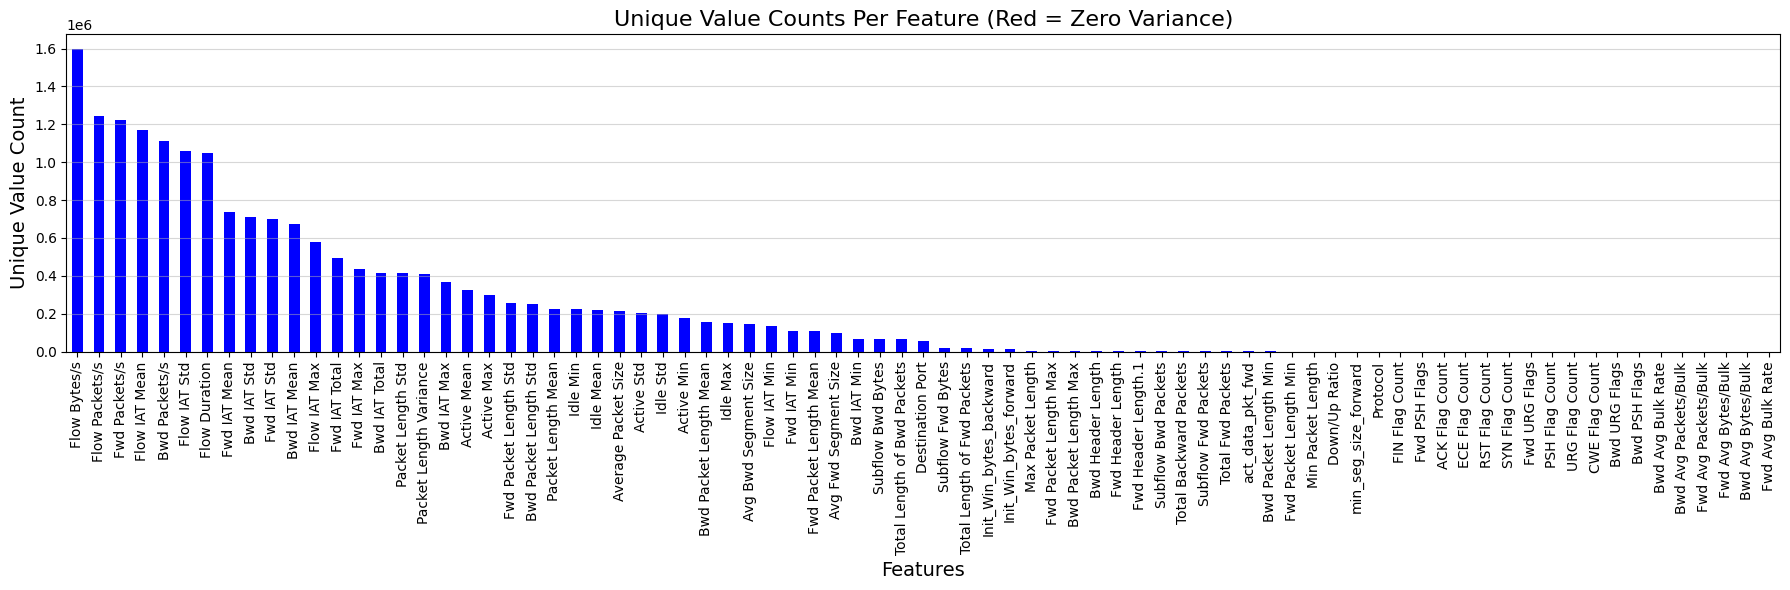


Proof: Found and Dropped 8 zero-variance columns.
Shape after dropping zero-variance columns: (2520158, 72)


In [ ]:
# Calculate unique value counts for all columns (excluding the 'Label')
unique_counts = df.drop(columns=['Label']).nunique().sort_values(ascending=False)
zero_var_cols = unique_counts[unique_counts <= 1].index.tolist()

# Visual Proof: Plotting Unique Value Counts
plt.figure(figsize=(18, 6))
# Create a color list: red for zero-variance, blue for others
colors = ['red' if col in zero_var_cols else 'blue' for col in unique_counts.index]
unique_counts.plot(kind='bar', color=colors)

plt.title('Unique Value Counts Per Feature (Red = Zero Variance)', fontsize=16)
plt.ylabel('Unique Value Count', fontsize=14)
plt.xlabel('Features', fontsize=14)
plt.xticks(rotation=90, fontsize=10)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()


# Action: Drop the zero-variance columns
df.drop(columns=zero_var_cols, inplace=True, errors='ignore')

print(f"\nProof: Found and Dropped {len(zero_var_cols)} zero-variance columns.")
print(f"Shape after dropping zero-variance columns: {df.shape}")

## 5️⃣ Redundancy Check 2: Identical Columns
**Rationale:** This is a specialized, fast check for features that are perfect duplicates (correlation = 1.0). We remove the second column from any identical pair.

In [ ]:
# Find pairs of identical columns
column_pairs = [(i,j) for i,j in combinations(df.columns, 2) if df[i].equals(df[j])]
ide_cols=[]
for col_pair in column_pairs:
    # We choose to drop the second column in the pair
    ide_cols.append(col_pair[1])

# Drop only unique column names
ide_cols = list(set(ide_cols))

df.drop(columns=ide_cols, axis=1, inplace=True)

print(f"Columns which have identical values: {ide_cols} dropped!")
print(f"Shape after removing identical value columns: {df.shape}")

Columns which have identical values: ['Subflow Fwd Packets', 'Subflow Bwd Packets', 'Fwd Header Length.1', 'CWE Flag Count', 'SYN Flag Count'] dropped!
Shape after removing identical value columns: (2520158, 67)


# 6️⃣ Redundancy Check 3: High Correlation ($\ge 0.95$)
**Rationale & Proof:** The paper mandates removing one feature from any pair that exhibits a correlation coefficient of **0.95 or higher**. The **Hot-Cold Correlation Matrix (Heatmap)** below visually demonstrates which features are highly correlated (bright colors) before we remove the redundant ones.

Calculating correlation matrix... (This might take a moment)


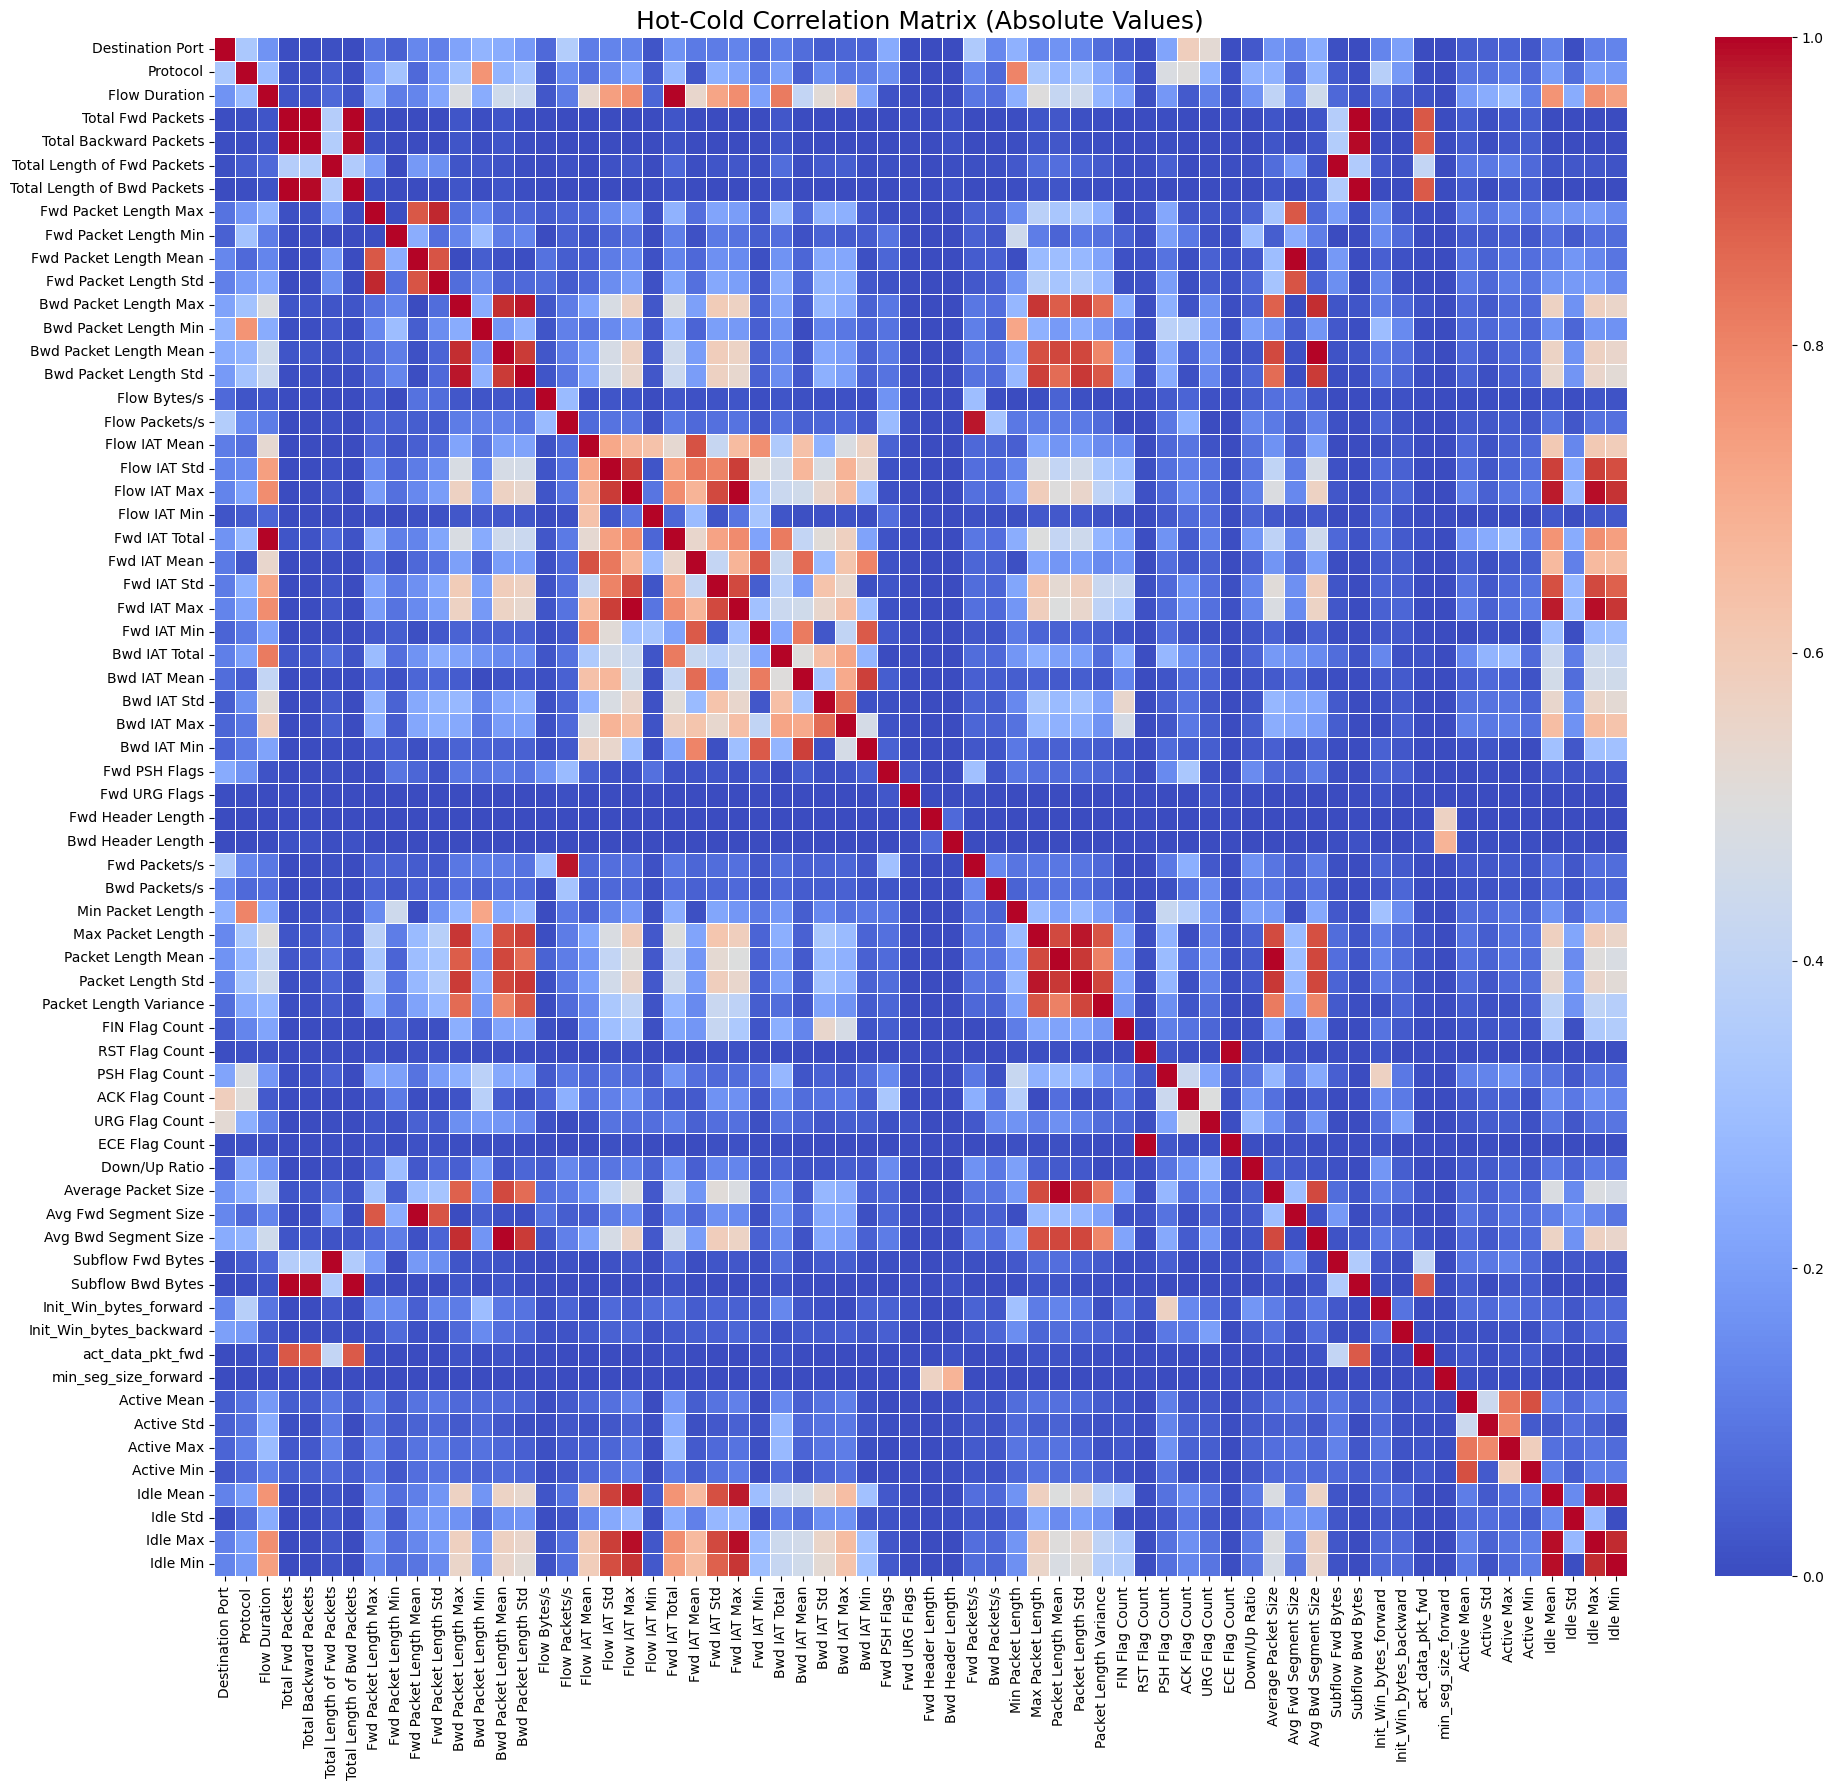


Proof: Found and Dropped 18 highly correlated features.
Final Feature Count: 49


In [ ]:
# Update numerical features list after previous drops
numerical_features = df.select_dtypes(include=np.number).columns

print("Calculating correlation matrix... (This might take a moment)")
# Calculate correlation matrix (absolute values)
corr_matrix = df[numerical_features].corr().abs()

# Visual Proof: Hot-Cold Correlation Matrix
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=0, vmax=1, annot=False, linewidths=.5)
plt.title('Hot-Cold Correlation Matrix (Absolute Values)', fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


# Action: Identify and drop columns
# Identify columns to drop (only look at the upper triangle to avoid duplicates and self-correlation)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] >= 0.95)]

df.drop(columns=to_drop, inplace=True)

print(f"\nProof: Found and Dropped {len(to_drop)} highly correlated features.")
print(f"Final Feature Count: {df.shape[1]}")

# 7️⃣ Class Balancing (Random Undersampling - 80/20 Rule)
**Rationale:** We implement the paper's specific undersampling method: minority classes (non-BENIGN, non-DoS) remain untouched (20% of the final data), while majority classes are randomly undersampled to constitute the remaining 80%.

In [ ]:
# 1. Separate Majority (BENIGN, DoS) and Minority
majority_labels = ['BENIGN', 'DoS']
minority_df = df[~df['Label'].isin(majority_labels)]

# 2. Calculate Target Counts
# Minority count represents 20%. So Target Majority = Minority * (80/20) = Minority * 4
minority_count = len(minority_df)
target_majority = int(minority_count * 4)

print(f"Minority Count (fixed): {minority_count}")
print(f"Target Majority Count (calculated): {target_majority}")

# 3. Sample Majority Data proportionally
benign_count = len(df[df['Label'] == 'BENIGN'])
dos_count = len(df[df['Label'] == 'DoS'])
total_existing_majority = benign_count + dos_count

# Calculate how the target majority should be split between BENIGN and DoS
benign_ratio = benign_count / total_existing_majority
dos_ratio = dos_count / total_existing_majority

# Perform the sampling
# Ensure the sampling size does not exceed the actual count if the ratio calculation results in a slightly smaller number
sampled_benign = df[df['Label'] == 'BENIGN'].sample(n=min(benign_count, int(target_majority * benign_ratio)), random_state=42)
sampled_dos = df[df['Label'] == 'DoS'].sample(n=min(dos_count, int(target_majority * dos_ratio)), random_state=42)

# 4. Combine and Shuffle
df_balanced = pd.concat([minority_df, sampled_benign, sampled_dos]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nFinal Balanced Dataset Shape: {df_balanced.shape}")
print("\nFinal Class Distribution:")
print(df_balanced['Label'].value_counts())

Minority Count (fixed): 103407
Target Majority Count (calculated): 413628

Final Balanced Dataset Shape: (517034, 49)

Final Class Distribution:
Label
BENIGN          358563
PortScan         90130
DoS              55064
Brute Force       9150
Web Attack        2143
Bot               1948
Infiltration        36
Name: count, dtype: int64


# 8️⃣ Final Label Encoding
**Rationale:** The `RandomForestClassifier` requires all inputs to be numerical. Now that we have selected our features and balanced our classes, we convert the string `Label` column into integers.

In [ ]:
# Initialize the encoder
le = LabelEncoder()

# Fit and transform the balanced DataFrame
df_balanced['Label_Encoded'] = le.fit_transform(df_balanced['Label'])

# Print the final mapping used for documentation
print("Final Label to Numerical Mapping:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

# Drop the original string Label column
df_balanced.drop(columns=['Label'], inplace=True)

# Rename the encoded column to 'Label' for consistency
df_balanced.rename(columns={'Label_Encoded': 'Label'}, inplace=True)

print("\nEncoding complete. 'Label' column is now numerical.")

Final Label to Numerical Mapping:
{'BENIGN': np.int64(0), 'Bot': np.int64(1), 'Brute Force': np.int64(2), 'DoS': np.int64(3), 'Infiltration': np.int64(4), 'PortScan': np.int64(5), 'Web Attack': np.int64(6)}

Encoding complete. 'Label' column is now numerical.


In [ ]:
# Identifying Missing Values
missing_val = df_balanced.isna().sum()
print("missing values",missing_val.sum())


# Checking for infinity values
numeric_cols = df_balanced.select_dtypes(include = np.number).columns
inf_count = np.isinf(df_balanced[numeric_cols]).sum()
print("inf values",inf_count.sum())

# checking for duplicates
print("duplicates",df_balanced.duplicated().sum())

missing values 0
inf values 0
duplicates 0


In [ ]:
df_balanced.dropna(inplace= True)
df_balanced.drop_duplicates(inplace= True)

In [ ]:
df_balanced.shape

(517034, 49)

# 9️⃣ Save Final ML Dataset
The fully preprocessed, feature-engineered, balanced, and encoded dataset is saved to this file. This file will be the direct input for model training in the next milestone.

In [ ]:
# Save the final, balanced, feature-selected dataset
ml_data_path = "/content/drive/MyDrive/Depi Project/Cleaned Data/ML_Data_Balanced.parquet"
df_balanced.to_parquet(ml_data_path, index=False)

print(f"Process Complete. ML-Ready data saved to: {ml_data_path}")

Process Complete. ML-Ready data saved to: /content/drive/MyDrive/Depi Project/Cleaned Data/ML_Data_Balanced.parquet
